In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [2]:
true_proportions = pd.read_table("../data/xin/proportions.txt", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None
true_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.716216,0.175676,0.067568,0.040541
Non T2D 10,0.418605,0.534884,0.046512,0.000000
Non T2D 11,0.796610,0.169492,0.016949,0.016949
Non T2D 12,0.626866,0.358209,0.014925,0.000000
Non T2D 2,0.166667,0.541667,0.083333,0.208333
Non T2D 3,0.642857,0.238095,0.071429,0.047619
Non T2D 4,0.518519,0.370370,0.000000,0.111111
Non T2D 5,0.442308,0.423077,0.096154,0.038462
Non T2D 6,0.750000,0.145833,0.083333,0.020833
Non T2D 7,0.296296,0.555556,0.000000,0.148148


In [13]:
cs_proportions = pd.read_table("3rd-party/cibersort/xin/cibersort_proportions.txt", index_col=0)
cs_proportions = cs_proportions.iloc[:, :-3]
cs_proportions = cs_proportions.sort_index(axis="columns").sort_index(axis="rows")
cs_proportions.index.name = None
cs_proportions

FileNotFoundError: [Errno 2] No such file or directory: '3rd-party/cibersort/xin/cibersort_proportions.txt'

In [14]:
deconv_proportions = pd.read_csv("out/xin/nb/proportions_separate_bd.tsv", sep="\t", index_col=0)
deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
deconv_proportions

,alpha,beta,delta,gamma
D1,0.565648,0.241523,0.056340,0.136490
D2,0.189725,0.321057,0.146149,0.343069
D3,0.264069,0.405262,0.055376,0.275293
D4,0.775606,0.031644,0.049728,0.143022
D5,0.671394,0.082908,0.056343,0.189355
D6,0.528209,0.161446,0.053312,0.257033
H1,0.792963,0.145750,0.016779,0.044508
H10,0.106248,0.497456,0.068252,0.328043
H11,0.367228,0.419574,0.117309,0.095890
H12,0.263865,0.201798,0.113104,0.421233


In [17]:
music_proportions = pd.read_csv("3rd-party/music/xin/music_proportions.csv", index_col=0)
music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
music_proportions.index.name = None
music_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.421269,0.536488,0.033483,0.008760
Non T2D 10,0.514780,0.444490,0.040730,0.000000
Non T2D 11,0.740086,0.242773,0.010546,0.006595
Non T2D 12,0.638644,0.356975,0.004381,0.000000
Non T2D 2,0.052573,0.893437,0.017240,0.036750
Non T2D 3,0.818588,0.109515,0.049301,0.022596
Non T2D 4,0.484339,0.415445,0.000000,0.100216
Non T2D 5,0.377824,0.531229,0.068855,0.022091
Non T2D 6,0.905897,0.026713,0.067390,0.000000
Non T2D 7,0.305537,0.590466,0.000000,0.103998


In [28]:
scaden_proportions = pd.read_csv("3rd-party/scaden/xin/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.605766,0.269062,0.037922,0.087249
Non T2D 10,0.380902,0.463801,0.068493,0.086804
Non T2D 11,0.514097,0.296886,0.042230,0.146787
Non T2D 12,0.523361,0.386476,0.026789,0.063374
Non T2D 2,0.179598,0.480330,0.078972,0.261100
Non T2D 3,0.468044,0.330252,0.084200,0.117503
Non T2D 4,0.383280,0.394448,0.033489,0.188783
Non T2D 5,0.388165,0.464595,0.087220,0.060020
Non T2D 6,0.547889,0.259040,0.079516,0.113554
Non T2D 7,0.293945,0.513243,0.025798,0.167013


In [30]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
# melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
# melt["cs"] = cs_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,scaden,music
0,Non T2D 1,alpha,0.716216,0.605766,0.421269
1,Non T2D 10,alpha,0.418605,0.380902,0.514780
2,Non T2D 11,alpha,0.796610,0.514097,0.740086
3,Non T2D 12,alpha,0.626866,0.523361,0.638644
4,Non T2D 2,alpha,0.166667,0.179598,0.052573
...,...,...,...,...,...
67,T2D 2,gamma,0.120482,0.186754,0.026645
68,T2D 3,gamma,0.050000,0.178797,0.030415
69,T2D 4,gamma,0.007143,0.060863,0.002148
70,T2D 5,gamma,0.006061,0.081705,0.000000


In [8]:
def ccc(est, true):
    p = np.corrcoef(est, true)[0,1]
    mu_est = np.mean(est)
    mu_true = np.mean(true)
    s_est = np.std(est)
    s_true = np.std(true)

    return (2.0 * p * s_est * s_true) / (s_est**2 + s_true**2 + (mu_est - mu_true)**2)

p_deconv = np.corrcoef(melt["true"], melt["deconv"])[0,1]
p_scaden = np.corrcoef(melt["true"], melt["scaden"])[0,1]
p_music = np.corrcoef(melt["true"], melt["music"])[0,1]
p_cs = np.corrcoef(melt["true"], melt["cs"])[0,1]

ccc_deconv = ccc(melt["true"], melt["deconv"])
ccc_scaden = ccc(melt["true"], melt["scaden"])
ccc_music = ccc(melt["true"], melt["music"])
ccc_cs = ccc(melt["true"], melt["cs"])

print("DeconV: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_deconv, ccc_deconv))
print("SCADEN: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_scaden, ccc_scaden))
print("MuSiC: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_music, ccc_music))
print("CIBERSORT: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_cs, ccc_cs))

DeconV: Pearson correlation coefficient: -0.481, CCC: -0.377
SCADEN: Pearson correlation coefficient: 0.175, CCC: 0.163
MuSiC: Pearson correlation coefficient: -0.380, CCC: -0.356
CIBERSORT: Pearson correlation coefficient: -0.247, CCC: -0.212


In [31]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None

# melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
# melt["deconv_squared_error"] = melt["deconv_error"]**2
# melt["cs_squared_error"] = melt["cs_error"]**2
# melt["cs_error"] = abs(melt["cs"] - melt["true"])
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
melt["scaden_squared_error"] = melt["scaden_error"]**2
melt["music_error"] = abs(melt["music"] - melt["true"])
melt["music_squared_error"] = melt["music_error"]**2

# temp = melt[["sample", "cell_type", "deconv", "deconv_error", "deconv_squared_error"]].rename(
#     columns={"deconv": "proportion", "deconv_error": "error", "deconv_squared_error": "squared_error"}
# )
# temp["type"] = "deconv"
# df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error", "scaden_squared_error"]].rename(
    columns={"scaden": "proportion", "scaden_error": "error", "scaden_squared_error": "squared_error"}
)
temp["type"] = "scaden"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "music", "music_error", "music_squared_error"]].rename(
    columns={"music": "proportion", "music_error": "error", "music_squared_error": "squared_error"}
)
temp["type"] = "music"
df = pd.concat([df, temp])

# temp = melt[["sample", "cell_type", "cs", "cs_error", "cs_squared_error"]].rename(
#     columns={"cs": "proportion", "cs_error": "error", "cs_squared_error": "squared_error"}
# )
# temp["type"] = "cs"
# df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error,squared_error
0,Non T2D 1,alpha,0.716216,true,NaN,NaN
1,Non T2D 10,alpha,0.418605,true,NaN,NaN
2,Non T2D 11,alpha,0.796610,true,NaN,NaN
3,Non T2D 12,alpha,0.626866,true,NaN,NaN
4,Non T2D 2,alpha,0.166667,true,NaN,NaN
...,...,...,...,...,...,...
67,T2D 2,gamma,0.026645,music,0.093836,0.008805
68,T2D 3,gamma,0.030415,music,0.019585,0.000384
69,T2D 4,gamma,0.002148,music,0.004995,0.000025
70,T2D 5,gamma,0.000000,music,0.006061,0.000037


/home/lutrarutra/.pyenv/versions/3.10.9/envs/lst/lib/python3.10/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.25'` for same effect.
  warnings.warn(msg, FutureWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


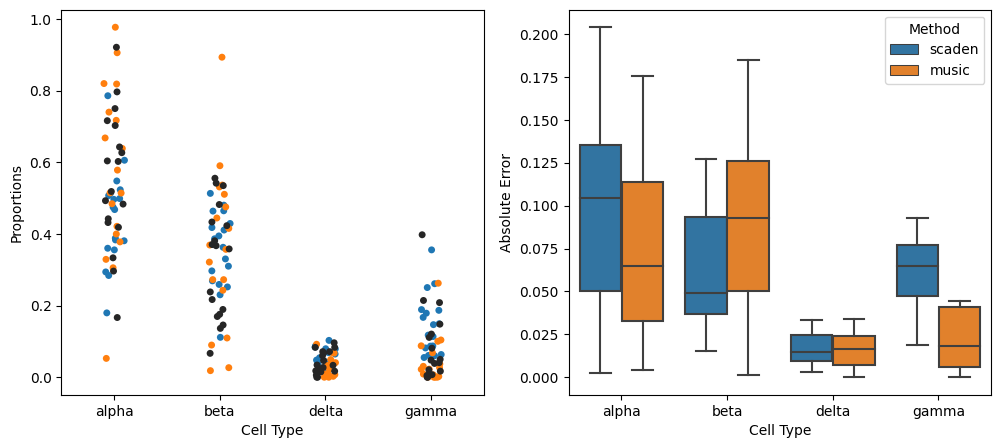

In [32]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df[df["type"] != "true"], x="cell_type", y="proportion", hue="type", ax=ax[0])
sns.stripplot(data=df[df["type"] == "true"], x="cell_type", y="proportion", hue="type", ax=ax[0], color=".25")
plt.legend(title="Method")
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)

ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
ax[0].set_xlabel("Cell Type")
ax[1].set_xlabel("Cell Type")
ax[0].get_legend().remove()
ax[1].get_legend().set_title("Method")

plt.savefig("comparison/pbmc/per_celltype.pdf", bbox_inches="tight")

plt.show()

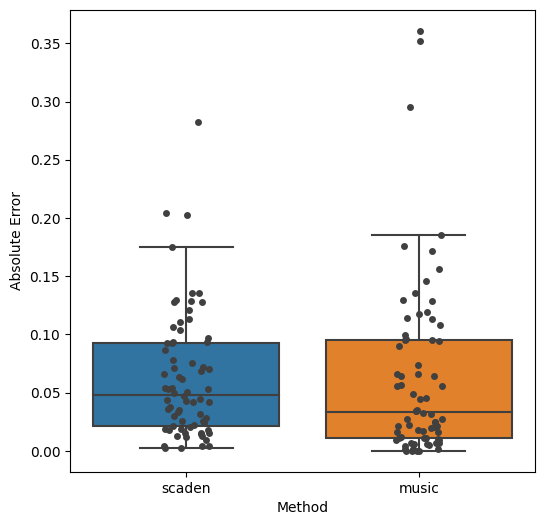

In [33]:
f, ax = plt.subplots(1, 1, figsize=(6,6), dpi=100)
sns.boxplot(data=df[df["type"] != "true"], y="error", x="type", showfliers=False, ax=ax)
sns.stripplot(data=df[df["type"] != "true"], x="type", y="error", ax=ax, color=".25")
ax.set_ylabel("Absolute Error")
ax.set_xlabel("Method")
plt.savefig("comparison/pbmc/box_abs_error.pdf", bbox_inches="tight")
plt.show()

In [26]:
df.groupby("type")[["error", "squared_error"]].mean()

,error,squared_error
type,,
music,0.063574,0.009764
true,NaN,NaN


In [35]:
# dv.pl.xypredictions(melt, x="true", y="scaden")